HW2 
StudentID:50

Sample code comprehension link:https://chatgpt.com/share/697c4bee-6fb0-8013-8dcc-513e1a0c7b70

Analysis of structures using spring elements. 

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def spring_element_k(k):
    return np.array([[k, -k],[-k, k]], dtype=float)

def assemble_global(Nodes, Elements, k_e):
    Nodes = np.asarray(Nodes, dtype=int)
    Elements = np.asarray(Elements, dtype=int)
    k_e = np.asarray(k_e, dtype=float)

    Nnd = len(Nodes)
    Kg = np.zeros((Nnd, Nnd), dtype=float)
    elem_dof = []
    Ke_all = []

    for (ni, nj), k in zip(Elements, k_e):
        Ke = spring_element_k(k)
        Ke_all.append(Ke)

        i = int(np.where(Nodes == ni)[0][0])
        j = int(np.where(Nodes == nj)[0][0])
        idx = np.array([i, j], dtype=int)
        elem_dof.append(idx)

        Kg[np.ix_(idx, idx)] += Ke

    return Nodes, Elements, Kg, elem_dof, Ke_all

def solve_with_constraints(Kg, F, prescribed):

    Kg = np.asarray(Kg, dtype=float)
    F = np.asarray(F, dtype=float).reshape(-1)
    n = Kg.shape[0]
    all_idx = np.arange(n, dtype=int)

    idx_c = np.array(sorted(prescribed.keys()), dtype=int)
    idx_f = np.array([i for i in all_idx if i not in set(idx_c)], dtype=int)

    u = np.zeros(n, dtype=float)
    u[idx_c] = np.array([prescribed[i] for i in idx_c], dtype=float)

    if len(idx_f) > 0:
        K_ff = Kg[np.ix_(idx_f, idx_f)]
        K_fc = Kg[np.ix_(idx_f, idx_c)]
        F_f = F[idx_f]
        rhs = F_f - K_fc @ u[idx_c]
        u[idx_f] = np.linalg.solve(K_ff, rhs)

    R = Kg @ u - F
    return u, R, idx_f, idx_c

def element_results(Nodes, Elements, k_e, u):
    """Returns list of dict per element."""
    Nodes = np.asarray(Nodes, dtype=int)
    Elements = np.asarray(Elements, dtype=int)
    k_e = np.asarray(k_e, dtype=float)
    u = np.asarray(u, dtype=float)

    out = []
    for e, ((ni, nj), k) in enumerate(zip(Elements, k_e)):
        i = int(np.where(Nodes == ni)[0][0])
        j = int(np.where(Nodes == nj)[0][0])
        ui, uj = u[i], u[j]
        du = uj - ui
        axial = k * du  # positive = extension (node j right of node i)
        fe = spring_element_k(k) @ np.array([ui, uj], dtype=float)
        out.append({
            "element": e+1, "ni": int(ni), "nj": int(nj), "k": float(k),
            "ui": float(ui), "uj": float(uj), "du": float(du),
            "axial_force": float(axial),
            "fe_i": float(fe[0]), "fe_j": float(fe[1])
        })
    return out

def plot_problem_1d(x, y, u, title):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    u = np.asarray(u, dtype=float)

    L = max(1.0, x.max() - x.min())
    amp = 0.25 * L
    scale = 1.0 if np.allclose(u, 0) else amp / np.max(np.abs(u))

    plt.figure()
    plt.plot(x, y, 'ok', label='Undeformed')
    plt.plot(x + u * scale, y, '*r', label='Deformed (scaled)')
    plt.title(title)
    plt.yticks([])
    plt.legend()
    plt.show()

u [in] = [0.  0.5 1. ]
reaction at node 1 [lb] = -500.0
{'element': 1, 'ni': 1, 'nj': 2, 'k': 1000.0, 'ui': 0.0, 'uj': 0.5, 'du': 0.5, 'axial_force': 500.0, 'fe_i': -500.0, 'fe_j': 500.0}
{'element': 2, 'ni': 2, 'nj': 3, 'k': 1000.0, 'ui': 0.5, 'uj': 1.0, 'du': 0.5, 'axial_force': 500.0, 'fe_i': -500.0, 'fe_j': 500.0}


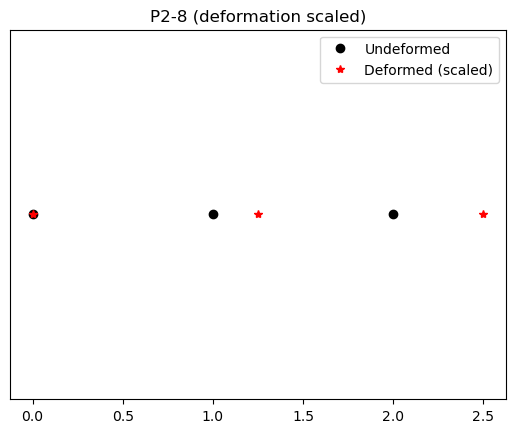

In [6]:
#2.8
Nodes = np.array([1,2,3])
Elements = np.array([(1,2),(2,3)])
k_e = np.array([1000.0, 1000.0])   # lb/in
F = np.array([0.0, 0.0, 500.0])    # lb

Nodes, Elements, Kg, edof, Ke_all = assemble_global(Nodes, Elements, k_e)

# Boundary condition: node 1 fixed (u1 = 0)
u, R, idx_free, idx_con = solve_with_constraints(Kg, F, {0:0.0})

print("u [in] =", u)
print("reaction at node 1 [lb] =", R[0])

for r in element_results(Nodes, Elements, k_e, u):
    print(r)

plot_problem_1d(x=[0,1,2], y=[0,0,0], u=u, title="P2-8 (deformation scaled)")

u [m] = [0.    0.015 0.02 ]
reaction at node 1 [N] = -15.0
required applied force F3 at node 3 [N] = 15.0
{'element': 1, 'ni': 1, 'nj': 2, 'k': 1000.0, 'ui': 0.0, 'uj': 0.015, 'du': 0.015, 'axial_force': 15.0, 'fe_i': -15.0, 'fe_j': 15.0}
{'element': 2, 'ni': 2, 'nj': 3, 'k': 3000.0, 'ui': 0.015, 'uj': 0.02, 'du': 0.005000000000000001, 'axial_force': 15.000000000000004, 'fe_i': -15.0, 'fe_j': 15.0}


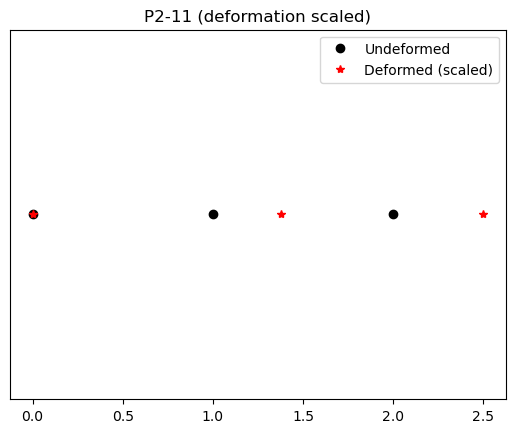

In [7]:
# 2.11
Nodes = np.array([1,2,3])
Elements = np.array([(1,2),(2,3)])
k_e = np.array([1000.0, 3000.0])   # N/m
F = np.array([0.0, 0.0, 0.0])      # N

Nodes, Elements, Kg, edof, Ke_all = assemble_global(Nodes, Elements, k_e)

delta = 20e-3  # m
# Boundary conditions: u1 = 0, u3 = delta
u, R, idx_free, idx_con = solve_with_constraints(Kg, F, {0:0.0, 2:delta})

print("u [m] =", u)
print("reaction at node 1 [N] =", R[0])
print("required applied force F3 at node 3 [N] =", R[2])

for r in element_results(Nodes, Elements, k_e, u):
    print(r)

plot_problem_1d(x=[0,1,2], y=[0,0,0], u=u, title="P2-11 (deformation scaled)")

u [m] = [0.    0.    0.002 0.   ] => u3 = 0.002 m
reactions at nodes 1,2,4 [kN] = [-1. -1. -2.]
{'element': 1, 'ni': 1, 'nj': 3, 'k': 500.0, 'ui': 0.0, 'uj': 0.002, 'du': 0.002, 'axial_force': 1.0, 'fe_i': -1.0, 'fe_j': 1.0}
{'element': 2, 'ni': 2, 'nj': 3, 'k': 500.0, 'ui': 0.0, 'uj': 0.002, 'du': 0.002, 'axial_force': 1.0, 'fe_i': -1.0, 'fe_j': 1.0}
{'element': 3, 'ni': 3, 'nj': 4, 'k': 1000.0, 'ui': 0.002, 'uj': 0.0, 'du': -0.002, 'axial_force': -2.0, 'fe_i': 2.0, 'fe_j': -2.0}


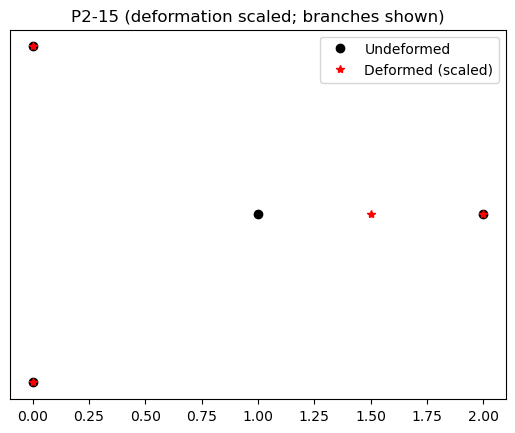

In [8]:
#2.15
Nodes = np.array([1,2,3,4])
Elements = np.array([(1,3),(2,3),(3,4)])
k_e = np.array([500.0, 500.0, 1000.0])  # kN/m
F = np.array([0.0, 0.0, 4.0, 0.0])      # kN

Nodes, Elements, Kg, edof, Ke_all = assemble_global(Nodes, Elements, k_e)

# Boundary conditions: u1 = u2 = u4 = 0
u, R, idx_free, idx_con = solve_with_constraints(Kg, F, {0:0.0, 1:0.0, 3:0.0})

print("u [m] =", u, "=> u3 =", u[2], "m")
print("reactions at nodes 1,2,4 [kN] =", R[[0,1,3]])

for r in element_results(Nodes, Elements, k_e, u):
    print(r)

# Branch-style plot
x_nodes = np.array([0,0,1,2], dtype=float)
y_nodes = np.array([ 0.5,-0.5,0.0,0.0], dtype=float)
plot_problem_1d(x=x_nodes, y=y_nodes, u=u, title="P2-15 (deformation scaled; branches shown)")

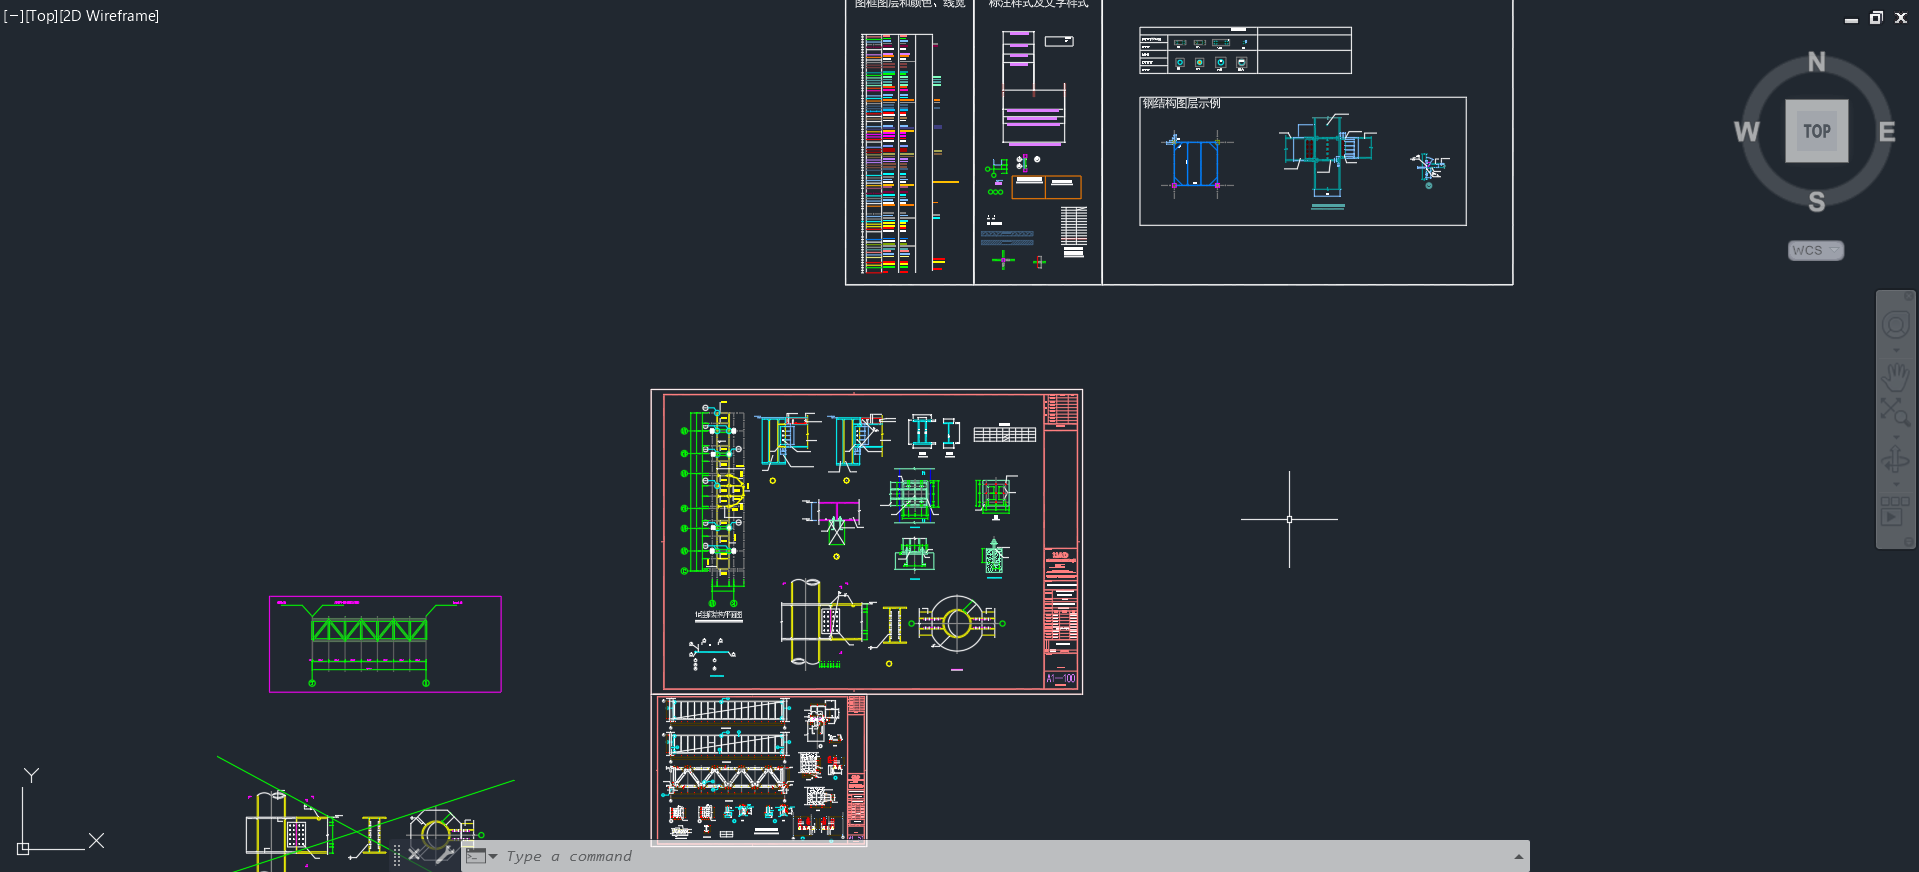

 5 structural engineering tasks
1. Develop and calibrate a finite element model from the design drawings to represent the structure’s geometry, materials, and connections for safety-critical analysis. 
2. Compute governing load combinations (dead, live, wind, seismic, and thermal) and check all members and connections against code-based strength limit states.
3. Perform modal identification and vibration-based checks using field monitoring data to verify dynamic behavior and flag abnormal changes that may indicate damage. 
4. Assess serviceability and stability (deflection, vibration, fatigue, and buckling) and revise detailing or member sizes where limits are exceeded.
5. Plan inspection, maintenance, and retrofit measures (e.g., strengthening, damping, or corrosion protection) based on analysis results and observed performance to keep the structure safe.